# Storm Catalog Diagnostics

Generate the full set of **storm-motion diagnostic plots** from a *storm catalog*
(a folder of NetCDF storm events produced by RainyDay).

You provide the inputs and parameters through a **JSON config** (`configs/`), or
override them inline below. The exact same pipeline runs headless from the command line:

```bash
python run_diagnostics.py --config configs/testing_data.json
```

In [8]:
# Make the package importable and pick up code edits without a manual kernel restart.
import os, sys
root = os.getcwd()
while not os.path.isdir(os.path.join(root, "stormcatalog_analyzer")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)
# drop any cached package modules so edits are re-read from disk on re-run
for _m in [m for m in list(sys.modules) if m.startswith("stormcatalog_analyzer")]:
    del sys.modules[_m]

from stormcatalog_analyzer.config import load_config
from stormcatalog_analyzer import pipeline
print("repo root:", root)

repo root: /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer


## 1. Configuration — inputs & parameters

Load a config file, then optionally override any field inline. All paths resolve
relative to `project_root` (the repo root by default).

In [ ]:
cfg = load_config("configs/testing_data.json")

# --- Optional inline overrides (edit to point at YOUR catalog) ---
cfg.io.max_events = 200 # limit the number of events to process (for testing)
# cfg.io.catalog_dir               = "testing_data/StormCatalog"
# cfg.io.transposition_domain_path = "testing_data/TranspositionDomain/Domain_58.shp"
# cfg.io.output_dir                = "testing_data"
# cfg.io.domain_name               = "Test Domain"
# cfg.tracking.morph_radius_cells       = 2       # storm-merging radius (cells)
# cfg.tracking.rainfall_threshold_mmhr  = 2     # rainfall threshold (mm/hr)
# cfg.selection.min_duration_hr         = 6       # drop storms shorter than this (hours)
# cfg.motion.intensity_window_hr        = 12      # window for the most-intense period (hours)
# cfg.motion.n_trajectories_plotted     = 100     # number of events on the trajectory map

cfg.validate()
cfg

Config(io=IOConfig(catalog_dir='testing_data/StormCatalog', transposition_domain_path='testing_data/TranspositionDomain/Domain_58.shp', control_area_path=None, grid_path=None, output_dir='testing_data', domain_name='Test Domain', max_events=200), tracking=TrackingConfig(rainfall_var_name='rain', morph_radius_cells=2, rainfall_threshold_mmhr=2, ellipse_fit_method='moments', overlap_ratio_threshold=0.2, dry_spell_hr=0), selection=SelectionConfig(min_duration_hr=6, min_area_fraction=0.05), motion=MotionConfig(intensity_window_hr=12, n_trajectories_plotted=100), figure=FigureConfig(font_size=0, dpi=300, smooth_factor=0.05, arrow_scale=1.0, arrow_width=0.005, head_width=2.0, head_length=1.5), direction_grid=DirectionGridConfig(n_sectors=4, cell_size_km=50.0, count_threshold=100, start_angle_deg=None), project_root='.')

## 2. Run the pipeline

`pipeline.run` performs three stages — **track** every event, **summarize** motion (direction/speed/trajectory per storm), and **generate** outputs — saving a per-storm **CSV** (`storm_properties_<domain>.csv`) and the diagnostic figures under `output_dir/<domain_name>/`.

In [10]:

out = pipeline.run(cfg)
summary = out["summary"]
print("per-storm CSV:", out["table"])
summary.storm_properties

The longest storm has a valid duration of 10 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2015-06-12T01:00:00.000000000 to 2015-06-12T10:00:00.000000000
Selected storm duration 10 hours
ok   IOWA_Domain.nc_storm_350_20150611.nc
The longest storm has a valid duration of 6 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2019-09-12T05:00:00.000000000 to 2019-09-12T10:00:00.000000000
Selected storm duration 6 hours
ok   IOWA_Domain.nc_storm_351_20190912.nc
The longest storm has a valid duration of 7 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2011-07-15T20:00:00.000000000 to 2011-07-16T02:00:00.000000000
Selected storm duration 7 hours
ok   IOWA_Domain.nc_storm_352_20110715.nc
The longest storm has a valid duration of 9 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2018-09-01T07:00:00.000000000 to 2018-09-01T15:00:00.000000000
Sele

/Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/stormcatalog_analyzer/plotting/diagnostics.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/stormcatalog_analyzer/plotting/diagnostics.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])



Saved storm-properties table:
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_properties_Test Domain.csv
Saved 3 figures:
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_trajectories_diagnostic_plot_Test Domain.png
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_direction_vector_plot_Test Domain.png
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_statistics_pairplot_Test Domain.png
per-storm CSV: /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_properties_Test Domain.csv


,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,angular_variance,mean_intensity_mmh,peak_intensity_mmh,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg
0,IOWA_Domain.nc_storm_350_20150611.nc,350,2015-06-12 01:00:00,2015-06-12 10:00:00,10,14.243626,30.120616,10.704149,0.338290,5.036433,73.250000,50.364334,68205.932444,410.216440,399.316362,170.265180,3.489199
1,IOWA_Domain.nc_storm_351_20190912.nc,351,2019-09-12 05:00:00,2019-09-12 10:00:00,6,11.177728,92.309782,74.295973,0.450513,5.948699,75.500000,35.692192,43214.523474,160.959289,322.770710,96.550508,-19.598952
2,IOWA_Domain.nc_storm_352_20110715.nc,352,2011-07-15 20:00:00,2011-07-16 02:00:00,7,9.229719,-30.381456,-21.877317,0.037741,16.481058,69.125000,115.367401,30653.727574,166.134949,177.073446,84.366016,25.536370
3,IOWA_Domain.nc_storm_353_20180901.nc,353,2018-09-01 07:00:00,2018-09-01 15:00:00,9,7.890155,26.579086,-16.366679,0.729705,5.373309,57.875000,48.359783,85885.691885,198.831898,371.233992,175.542568,25.679952
4,IOWA_Domain.nc_storm_354_20140603.nc,354,2014-06-04 00:00:00,2014-06-04 11:00:00,12,9.189861,-18.655415,-15.521841,0.197402,8.385397,62.562500,100.624763,103004.413936,330.834981,319.859907,180.069732,-7.852704
5,IOWA_Domain.nc_storm_355_20180820.nc,355,2018-08-20 02:00:00,2018-08-20 14:00:00,13,7.998606,55.004018,57.593076,0.288589,5.181616,42.437500,67.361008,70458.032605,316.744786,411.171483,148.372346,-50.297809
6,IOWA_Domain.nc_storm_356_20060910.nc,356,2006-09-11 02:00:00,2006-09-11 11:00:00,10,7.109660,27.500899,31.771919,0.030505,5.180866,46.750000,51.808662,50638.066852,204.758198,259.860483,151.012236,16.700266
7,IOWA_Domain.nc_storm_357_20100605.nc,357,2010-06-05 05:00:00,2010-06-05 16:00:00,12,7.148208,18.120916,27.229577,0.467603,8.913656,67.687500,106.963875,36177.742202,257.335488,233.667513,101.384261,-13.734301
8,IOWA_Domain.nc_storm_358_20190928.nc,358,2019-09-29 12:00:00,2019-09-29 21:00:00,10,8.987841,33.456996,55.403076,0.205411,6.000304,64.250000,60.003036,50410.925267,258.849817,268.801959,123.071909,-1.805905
9,IOWA_Domain.nc_storm_359_20070807.nc,359,2007-08-08 06:00:00,2007-08-08 16:00:00,11,6.799688,-172.462967,-115.330951,0.796717,5.300241,41.437500,58.302650,27960.941555,220.309885,210.682573,96.618929,5.648187


In [11]:
summary.storm_properties[summary.storm_properties["angular_variance"]<0.2]   # e.g. summary.storm_properties[summary.storm_properties["storm_name"].str.contains("112")].head()

,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,angular_variance,mean_intensity_mmh,peak_intensity_mmh,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg
2,IOWA_Domain.nc_storm_352_20110715.nc,352,2011-07-15 20:00:00,2011-07-16 02:00:00,7,9.229719,-30.381456,-21.877317,0.037741,16.481058,69.1250,115.367401,30653.727574,166.134949,177.073446,84.366016,25.536370
4,IOWA_Domain.nc_storm_354_20140603.nc,354,2014-06-04 00:00:00,2014-06-04 11:00:00,12,9.189861,-18.655415,-15.521841,0.197402,8.385397,62.5625,100.624763,103004.413936,330.834981,319.859907,180.069732,-7.852704
6,IOWA_Domain.nc_storm_356_20060910.nc,356,2006-09-11 02:00:00,2006-09-11 11:00:00,10,7.109660,27.500899,31.771919,0.030505,5.180866,46.7500,51.808662,50638.066852,204.758198,259.860483,151.012236,16.700266
10,IOWA_Domain.nc_storm_360_20020511.nc,360,2002-05-11 10:00:00,2002-05-11 18:00:00,9,12.745228,68.297660,66.203660,0.140481,4.974037,32.4375,44.766331,160765.130644,321.179756,439.865867,254.374696,-43.328228
28,IOWA_Domain.nc_storm_378_20170721.nc,378,2017-07-21 13:00:00,2017-07-21 19:00:00,7,4.827969,-10.384366,-11.330190,0.128534,5.293071,38.1250,37.051498,45668.898605,86.903436,311.126799,123.429046,-14.461154
29,IOWA_Domain.nc_storm_379_20150828.nc,379,2015-08-28 11:00:00,2015-08-28 23:00:00,13,5.975819,22.857958,16.953915,0.039836,7.070029,74.2500,91.910378,70889.462396,236.642420,273.713642,138.404468,52.986353
32,IOWA_Domain.nc_storm_383_20150624.nc,383,2015-06-24 09:00:00,2015-06-24 17:00:00,9,11.385352,-42.310231,-38.112643,0.094273,5.447220,32.8125,49.024982,39498.867331,286.910858,301.912009,102.942398,-17.753383
36,IOWA_Domain.nc_storm_387_20080724.nc,387,2008-07-24 11:00:00,2008-07-24 19:00:00,9,6.712005,-40.619099,-44.823932,0.095907,6.118321,38.2500,55.064888,69132.488210,169.142519,289.351758,138.807987,-36.562554
37,IOWA_Domain.nc_storm_388_20170628.nc,388,2017-06-29 00:00:00,2017-06-29 10:00:00,11,10.541847,-108.305852,-87.916565,0.177241,8.155122,81.3750,89.706345,44322.622923,341.555857,346.260164,112.090289,16.073869
39,IOWA_Domain.nc_storm_390_20070506.nc,390,2007-05-06 11:00:00,2007-05-06 23:00:00,13,7.552742,-23.767333,-18.848250,0.161383,6.758042,49.7500,87.854546,79202.216646,299.088572,398.896426,129.266952,29.516881


## 3. Diagnostic figures

The full diagnostic set: storm-trajectory map + wind rose + direction/speed
distributions, the per-storm mean-direction vectors, and the storm-statistics pairplot.

storm_trajectories_diagnostic_plot_Test Domain.png


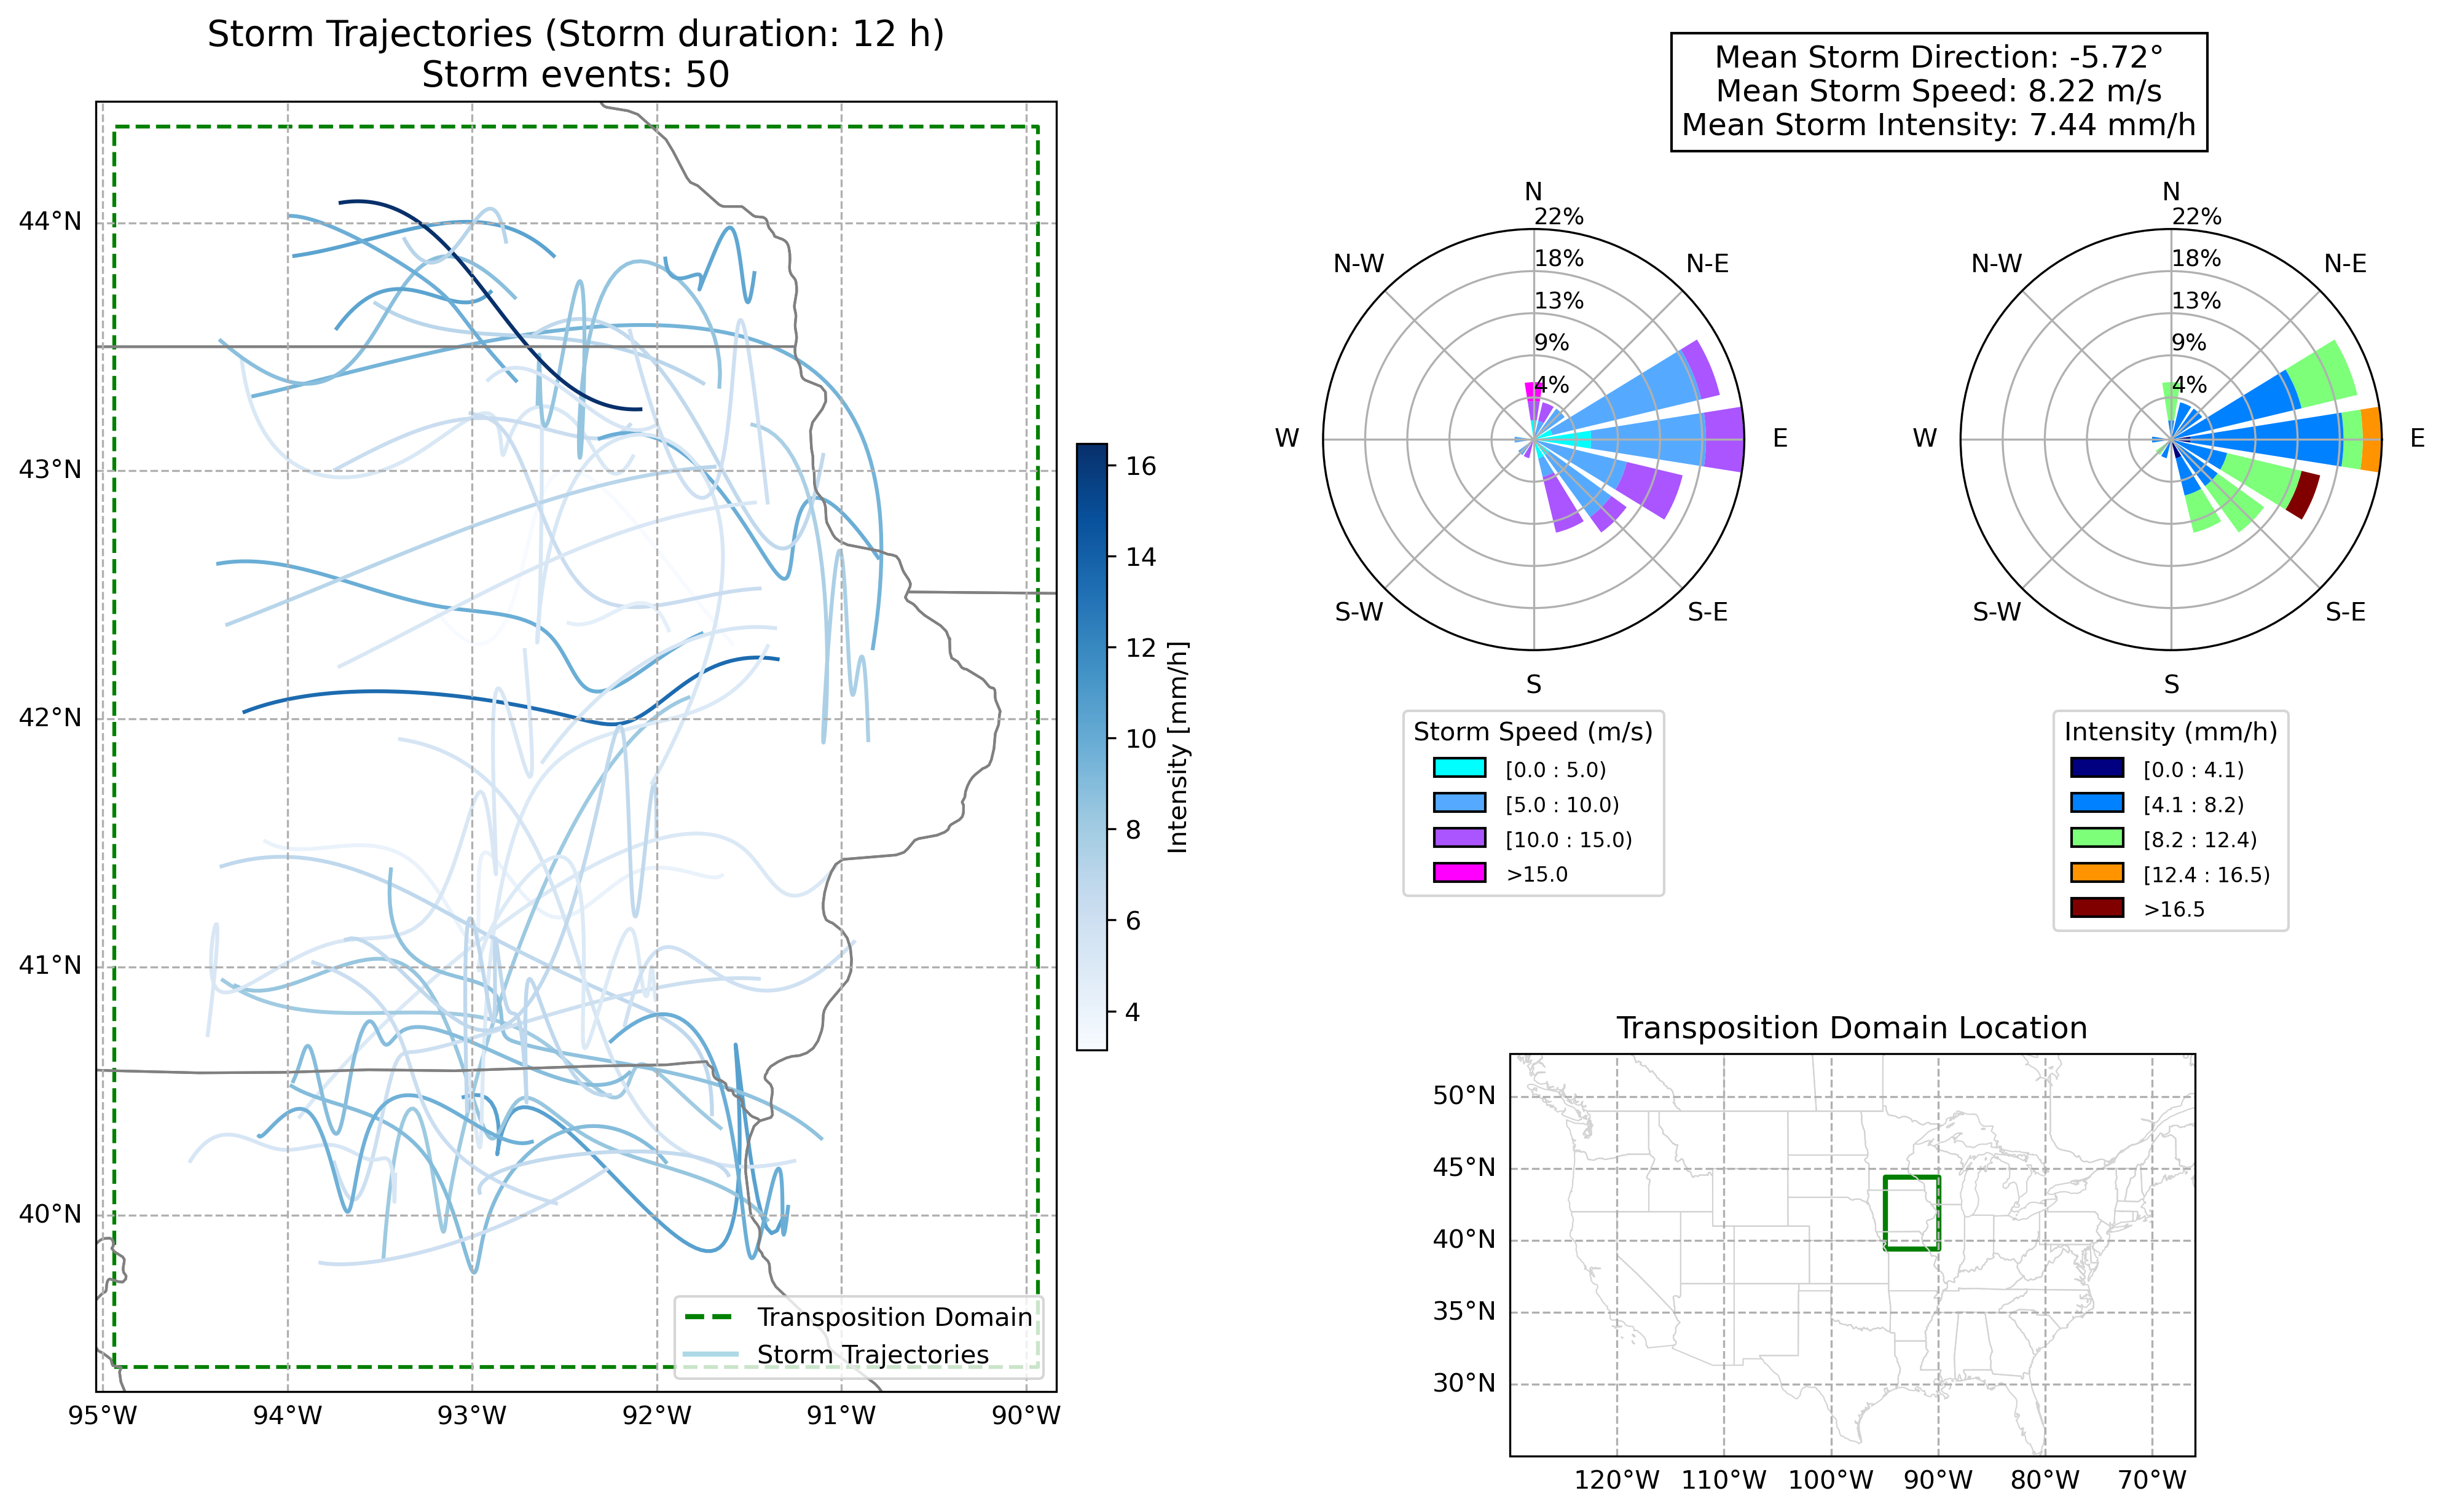

storm_direction_vector_plot_Test Domain.png


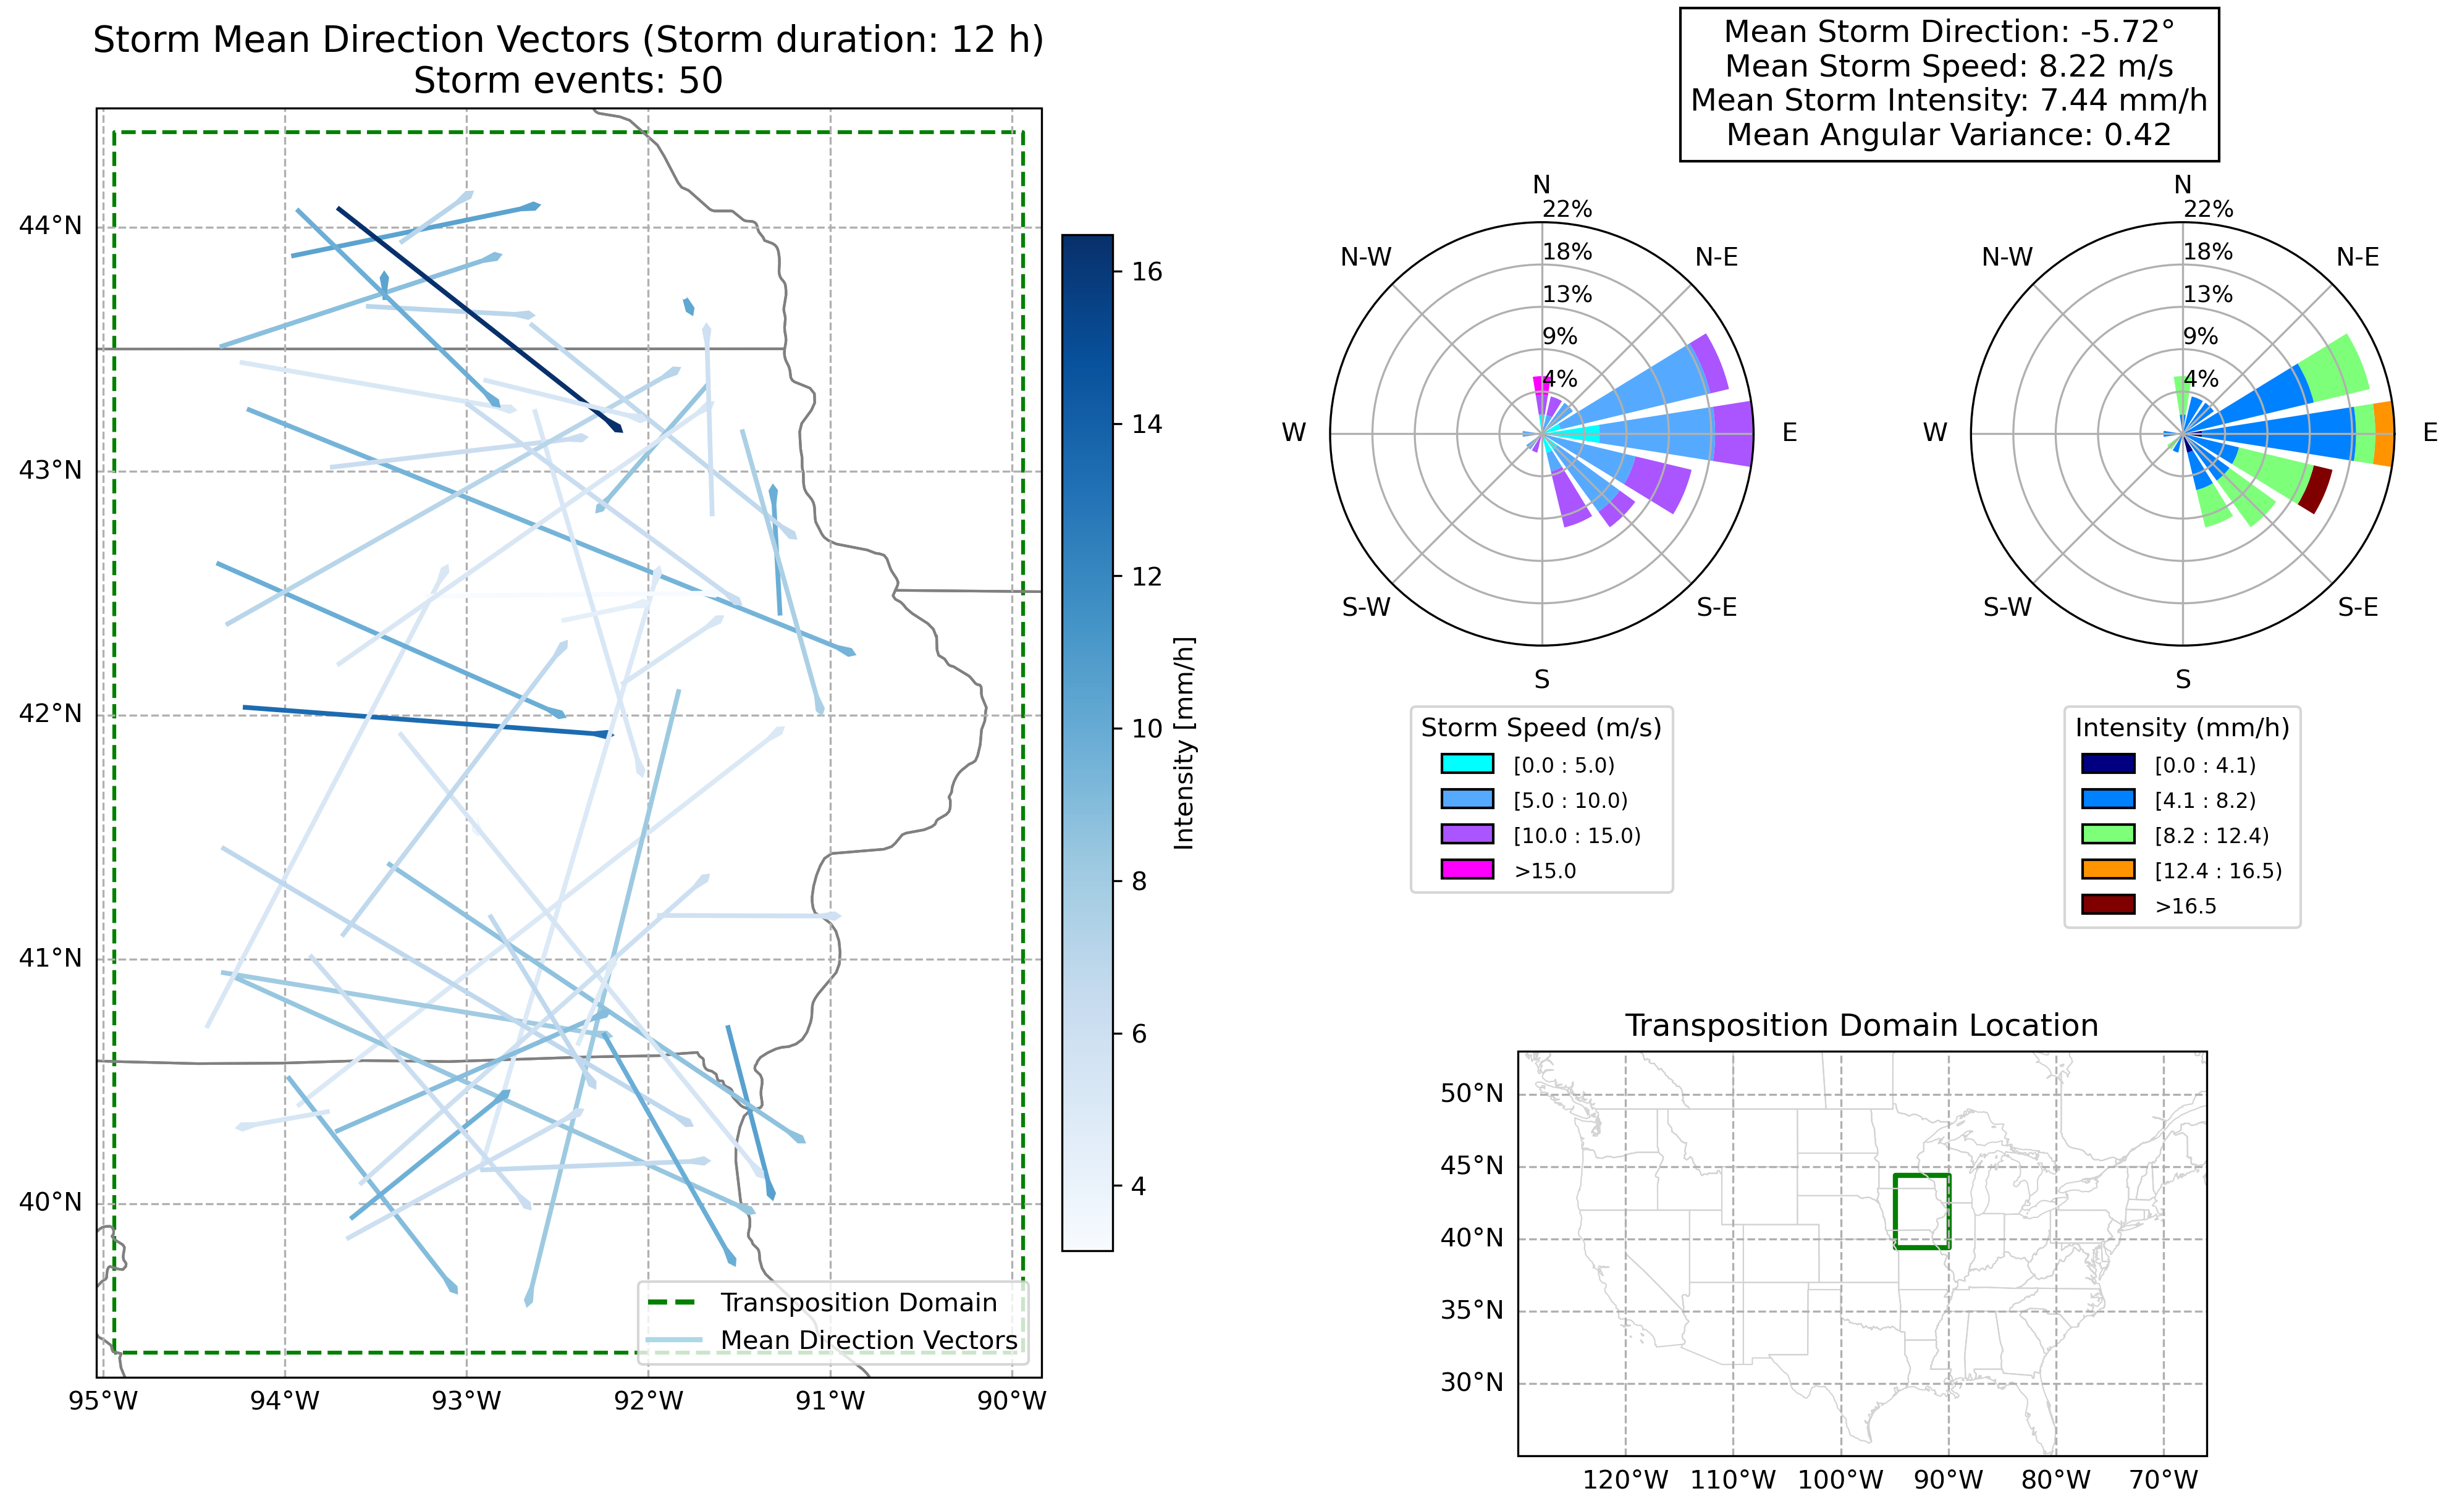

storm_statistics_pairplot_Test Domain.png


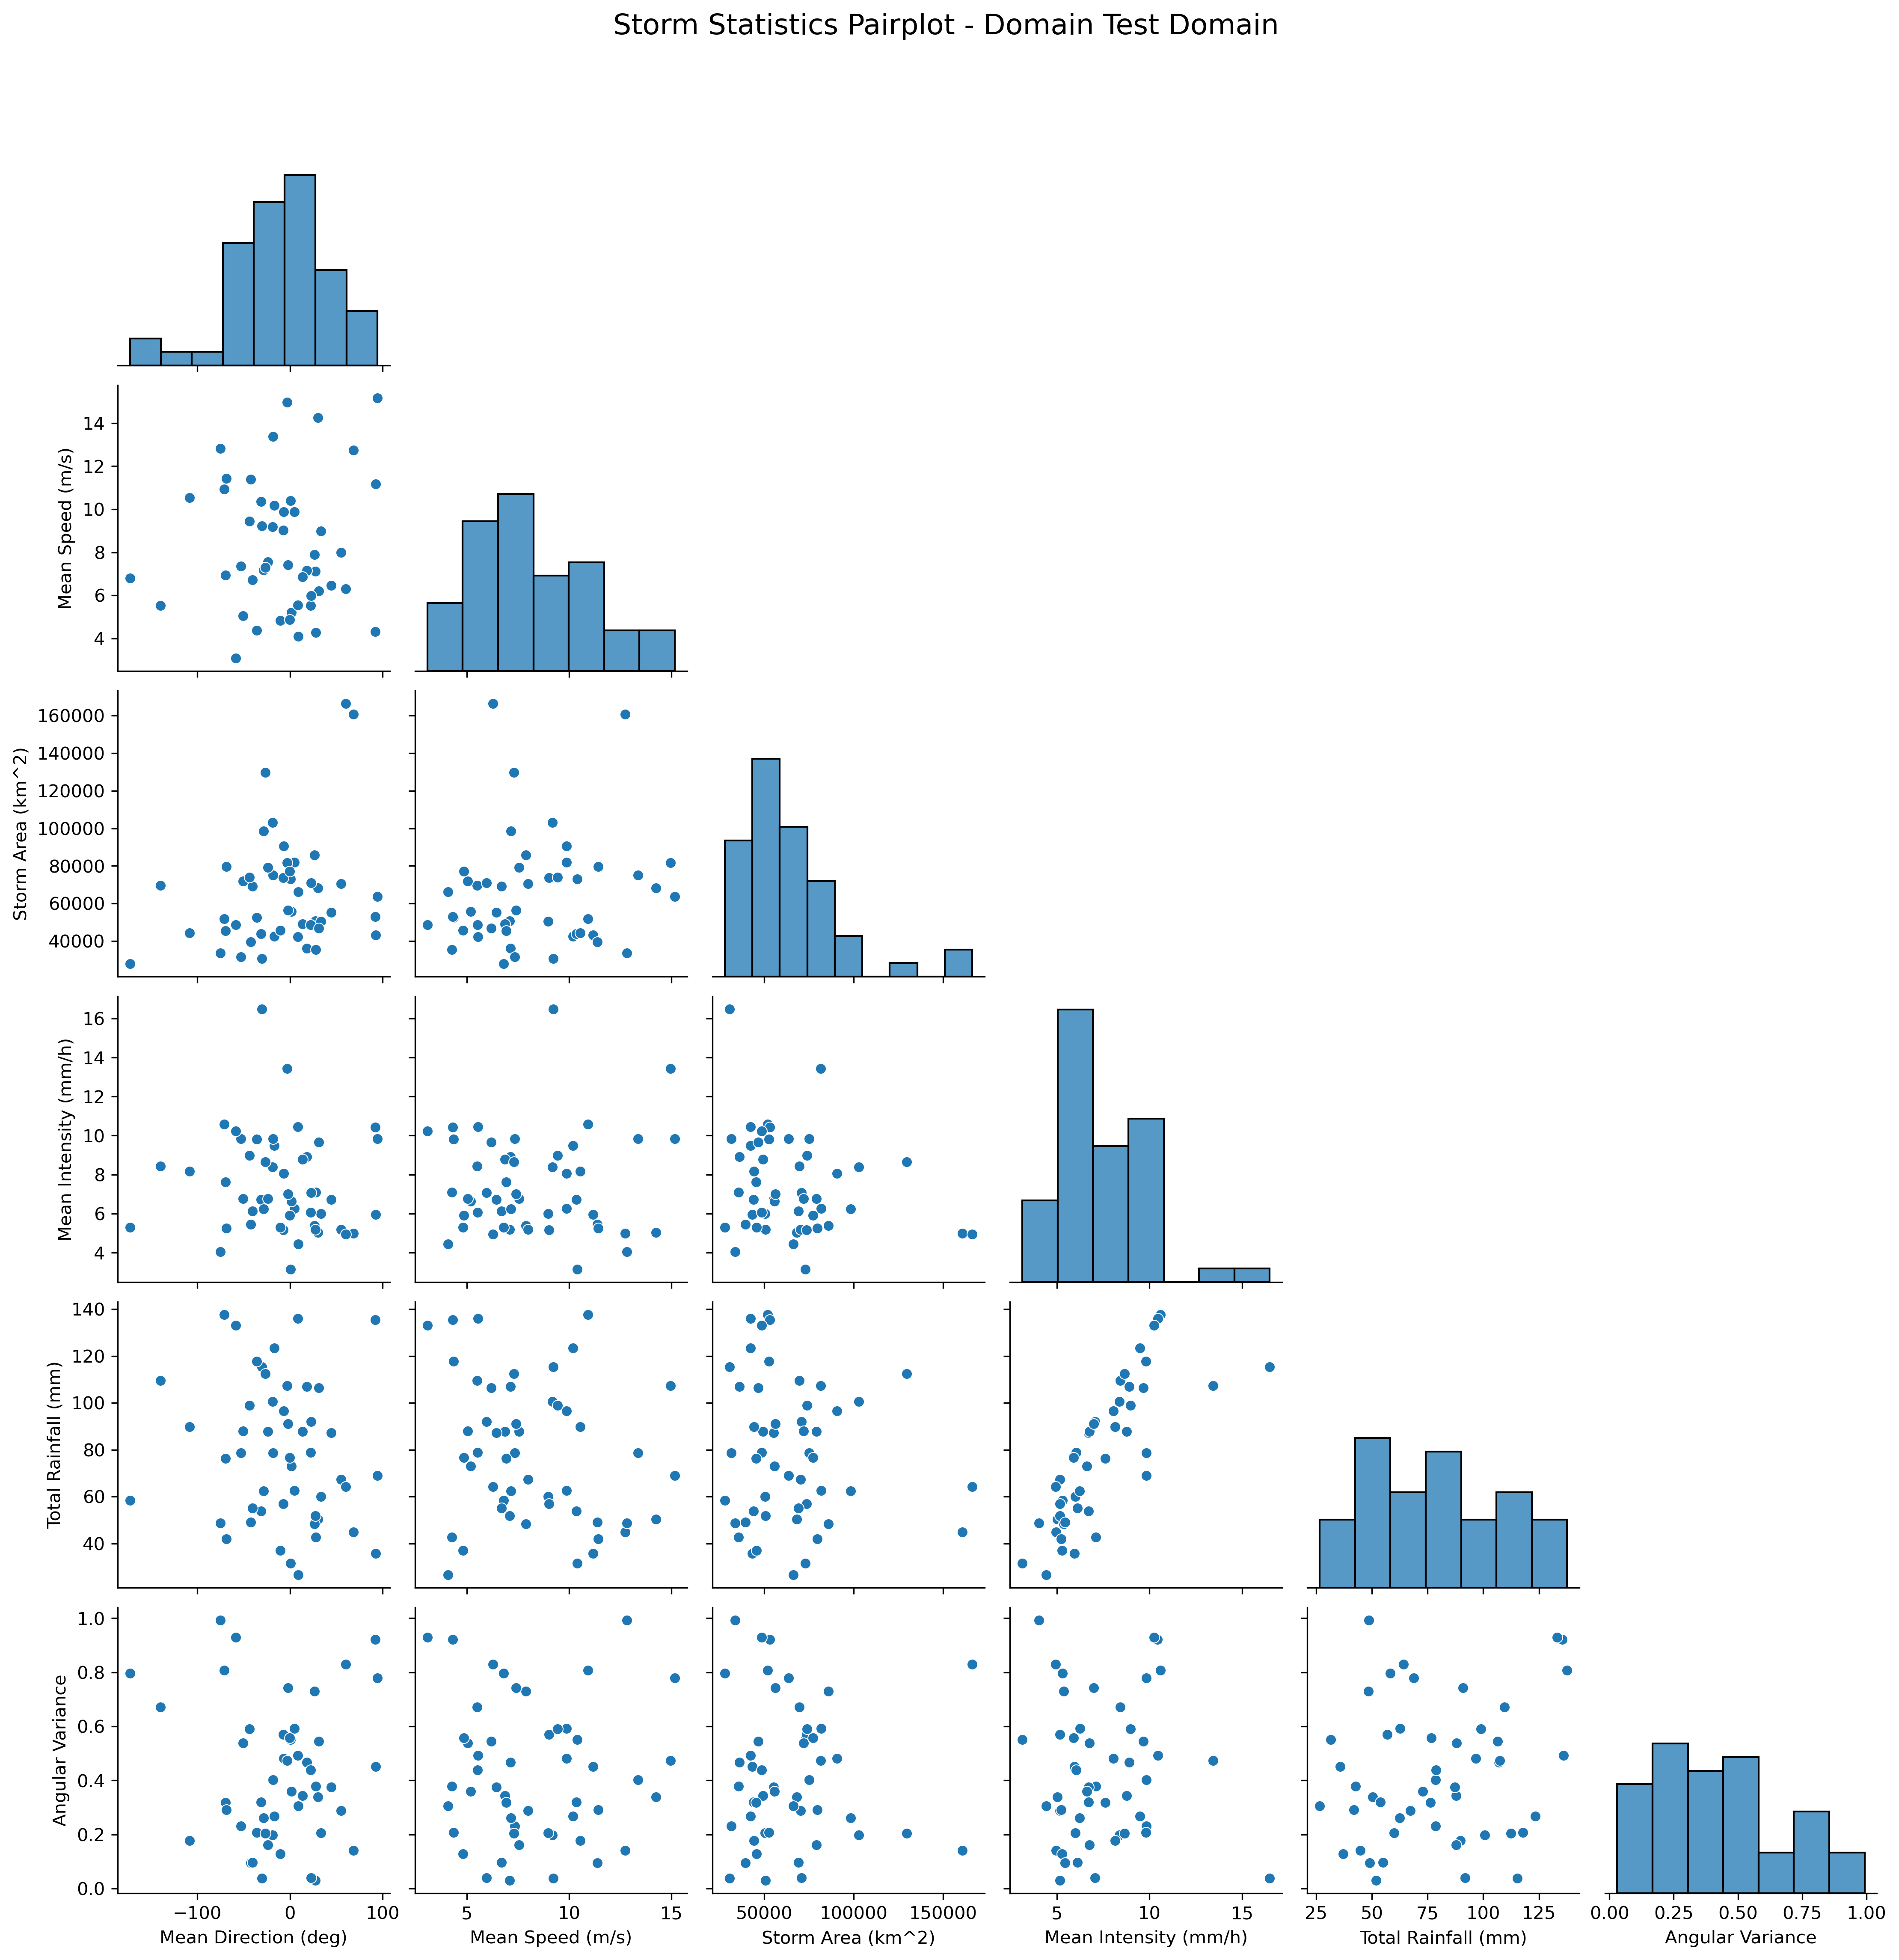

In [12]:
from IPython.display import Image, display
for fig_path in out["figures"]:
    print(fig_path.name)
    display(Image(filename=str(fig_path)))

## 4. Individual per-event figures (all storms)

Generate the storm-track + time-step panels for **every** storm in the catalog
(2 figures per storm). This reuses the tracking results from step 2 (no re-tracking),
but is still slow for large catalogs — subsample with `cfg.io.max_events` if needed.
Figures are saved under `StormTrack/` and `StormTimeSteps/`.


In [13]:
event_figs = pipeline.generate_all_event_diagnostics(cfg, out["results"], summary)
print(f"saved {len(event_figs)} per-event figures")

  per-event figures: 25/50 storms
  per-event figures: 50/50 storms
Saved 100 per-event figures for 50 storms under
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/StormTrack
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/StormTimeSteps
saved 100 per-event figures


## 5. Storm-motion direction probability (grid diagnostic)

Build a storm-motion grid per storm, aggregate them into a per-cell **direction-
probability field** (four quadrants I–IV), and render the 4-panel summary:
(a) total directional counts, (b) transposition-domain location, (c) direction-
probability fields, (d) direction regions. Panel (b)'s grid index labels require the
CONUS reference grid (`cfg.io.grid_path`); they are skipped when it is not set.

Uses every retained storm — subsample with `cfg.io.max_events` for a quick look.


Built 50 storm-motion grids (20 km cells); 4 sectors (90 deg each).


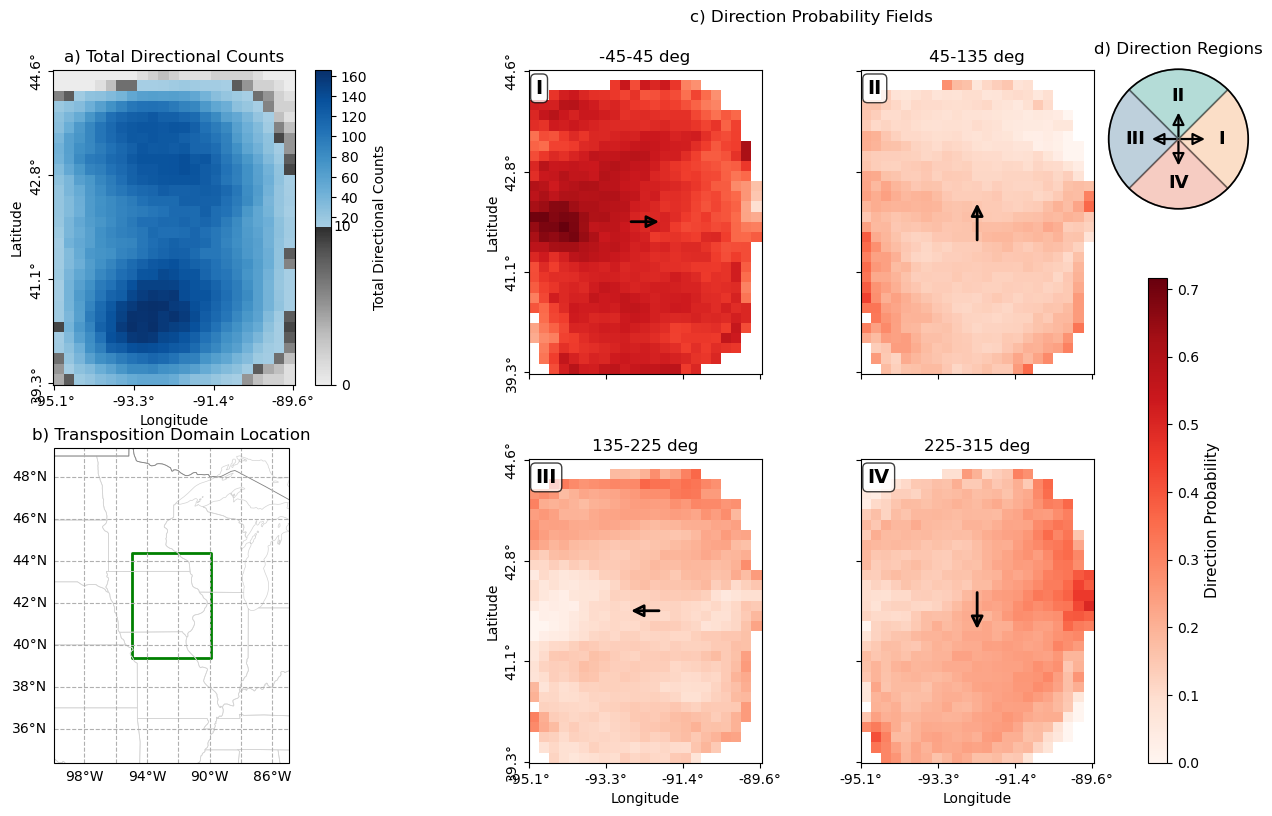

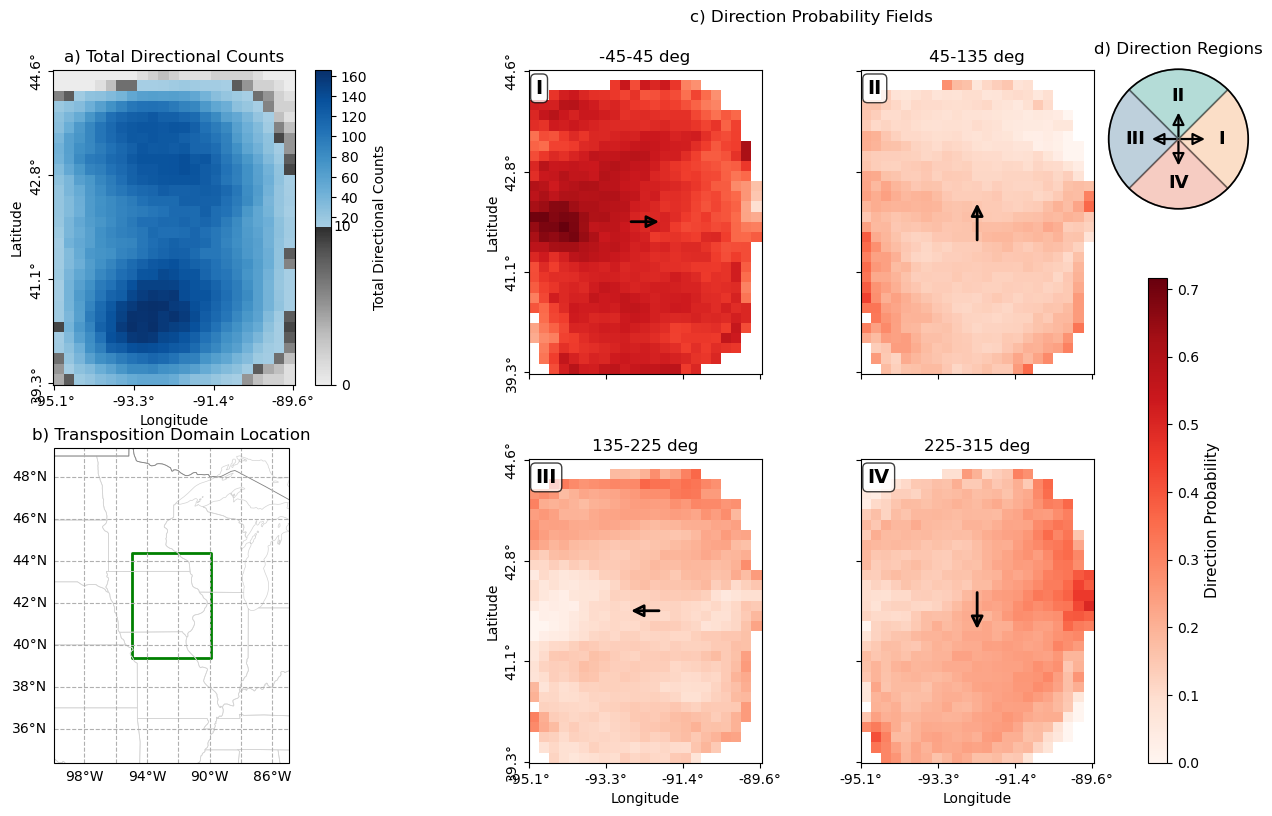

In [14]:
from stormcatalog_analyzer.plotting.motion_grid import plot_direction_probability_summary
from stormcatalog_analyzer import io as scio

# Number of sectors, grid resolution, etc. come from cfg.direction_grid
# (edit configs/testing_data.json -> "direction_grid": {"n_sectors": 8, ...})
cfg.direction_grid.n_sectors = 4
cfg.direction_grid.cell_size_km = 20
cfg.direction_grid.start_angle_deg = -45
cfg.direction_grid.count_threshold = 10
  # limit number of events to process (for testing)
prob_field = pipeline.build_direction_probability_field(out["results"], cfg)
transposition_domain = scio.load_vector(cfg.transposition_domain_path)
grid = scio.load_vector(cfg.grid_path)   # CONUS 5x5 reference grid (optional)

plot_direction_probability_summary(
    prob_field, transposition_domain, grid,
    count_threshold=cfg.direction_grid.count_threshold,
)